In [1]:
# Dependencies
import nfl_data_py as nfl
import pandas as pd
import numpy as np
import os
import urllib.request
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
import sys
notebook_dir = os.path.abspath(os.path.dirname(''))
project_root = os.path.dirname(notebook_dir)
sys.path.append(project_root)

In [2]:
from src.features import team_level_features_class

In [3]:
obj=team_level_features_class.TeamLevelFeatures()

Successfully connected to the database!
creating efficiency stats


100%|██████████| 5/5 [00:00<00:00, 495.84it/s]


building team stats


100%|██████████| 25/25 [00:25<00:00,  1.03s/it]


In [4]:
# Pull the team description 
logos = nfl.import_team_desc()

logos.head()

,team_abbr,team_name,team_id,team_nick,team_conf,team_division,team_color,team_color2,team_color3,team_color4,team_logo_wikipedia,team_logo_espn,team_wordmark,team_conference_logo,team_league_logo,team_logo_squared
0,ARI,Arizona Cardinals,3800,Cardinals,NFC,NFC West,#97233F,#000000,#ffb612,#a5acaf,https://upload.wikimedia.org/wikipedia/en/thum...,https://a.espncdn.com/i/teamlogos/nfl/500/ari.png,https://github.com/nflverse/nflverse-pbp/raw/m...,https://github.com/nflverse/nflverse-pbp/raw/m...,https://raw.githubusercontent.com/nflverse/nfl...,https://github.com/nflverse/nflverse-pbp/raw/m...
1,ATL,Atlanta Falcons,200,Falcons,NFC,NFC South,#A71930,#000000,#a5acaf,#a30d2d,https://upload.wikimedia.org/wikipedia/en/thum...,https://a.espncdn.com/i/teamlogos/nfl/500/atl.png,https://github.com/nflverse/nflverse-pbp/raw/m...,https://github.com/nflverse/nflverse-pbp/raw/m...,https://raw.githubusercontent.com/nflverse/nfl...,https://github.com/nflverse/nflverse-pbp/raw/m...
2,BAL,Baltimore Ravens,325,Ravens,AFC,AFC North,#241773,#9E7C0C,#9e7c0c,#c60c30,https://upload.wikimedia.org/wikipedia/en/thum...,https://a.espncdn.com/i/teamlogos/nfl/500/bal.png,https://github.com/nflverse/nflverse-pbp/raw/m...,https://github.com/nflverse/nflverse-pbp/raw/m...,https://raw.githubusercontent.com/nflverse/nfl...,https://github.com/nflverse/nflverse-pbp/raw/m...
3,BUF,Buffalo Bills,610,Bills,AFC,AFC East,#00338D,#C60C30,#0c2e82,#d50a0a,https://upload.wikimedia.org/wikipedia/en/thum...,https://a.espncdn.com/i/teamlogos/nfl/500/buf.png,https://github.com/nflverse/nflverse-pbp/raw/m...,https://github.com/nflverse/nflverse-pbp/raw/m...,https://raw.githubusercontent.com/nflverse/nfl...,https://github.com/nflverse/nflverse-pbp/raw/m...
4,CAR,Carolina Panthers,750,Panthers,NFC,NFC South,#0085CA,#000000,#bfc0bf,#0085ca,https://upload.wikimedia.org/wikipedia/en/thum...,https://a.espncdn.com/i/teamlogos/nfl/500-dark...,https://github.com/nflverse/nflverse-pbp/raw/m...,https://github.com/nflverse/nflverse-pbp/raw/m...,https://raw.githubusercontent.com/nflverse/nfl...,https://github.com/nflverse/nflverse-pbp/raw/m...


In [5]:
logos = logos[['team_abbr', 'team_logo_espn']]

In [22]:
# Initialize an empty list for the logo file paths
logo_paths = []

# Initialize an empty list for the team abbreviations
team_abbr = []
logo_path="C:/nfl_model/NFL_Model/src/data/logos"
for team in obj.teams:
    logo_paths.append(f"{logo_path}/{team}.tif")
logo_path_df=pd.DataFrame(logo_paths)
logo_path_df.index=obj.teams
logo_path_df

,0
ARI,C:/nfl_model/NFL_Model/src/data/logos/ARI.tif
ATL,C:/nfl_model/NFL_Model/src/data/logos/ATL.tif
BAL,C:/nfl_model/NFL_Model/src/data/logos/BAL.tif
BUF,C:/nfl_model/NFL_Model/src/data/logos/BUF.tif
CAR,C:/nfl_model/NFL_Model/src/data/logos/CAR.tif
CHI,C:/nfl_model/NFL_Model/src/data/logos/CHI.tif
CIN,C:/nfl_model/NFL_Model/src/data/logos/CIN.tif
CLE,C:/nfl_model/NFL_Model/src/data/logos/CLE.tif
DAL,C:/nfl_model/NFL_Model/src/data/logos/DAL.tif
DEN,C:/nfl_model/NFL_Model/src/data/logos/DEN.tif


In [ ]:
pd.DataFrame(logo_paths)

,0
0,C:/nfl_model/NFL_Model/src/data/logos/ARI.tif
1,C:/nfl_model/NFL_Model/src/data/logos/ATL.tif
2,C:/nfl_model/NFL_Model/src/data/logos/BAL.tif
3,C:/nfl_model/NFL_Model/src/data/logos/BUF.tif
4,C:/nfl_model/NFL_Model/src/data/logos/CAR.tif
5,C:/nfl_model/NFL_Model/src/data/logos/CHI.tif
6,C:/nfl_model/NFL_Model/src/data/logos/CIN.tif
7,C:/nfl_model/NFL_Model/src/data/logos/CLE.tif
8,C:/nfl_model/NFL_Model/src/data/logos/DAL.tif
9,C:/nfl_model/NFL_Model/src/data/logos/DEN.tif


In [64]:
x_stat="offensive total_yards_normalized"
y_stat="defensive total_yards_normalized"
columns=[x_stat, y_stat]
x=pd.DataFrame(obj.team_stats_dict[x_stat].iloc[-1])
y=pd.DataFrame(obj.team_stats_dict[y_stat].iloc[-1])
df=pd.concat([x,y,logo_path_df], axis=1)
df.columns=[x_stat, y_stat, "logo"]
df=df.drop(["NYJ"])
df

,offensive total_yards_normalized,defensive total_yards_normalized,logo
ARI,0.601607,0.184948,C:/nfl_model/NFL_Model/src/data/logos/ARI.tif
ATL,0.929183,0.296359,C:/nfl_model/NFL_Model/src/data/logos/ATL.tif
BAL,2.532057,-0.798725,C:/nfl_model/NFL_Model/src/data/logos/BAL.tif
BUF,0.664882,0.047476,C:/nfl_model/NFL_Model/src/data/logos/BUF.tif
CAR,-1.101124,2.794439,C:/nfl_model/NFL_Model/src/data/logos/CAR.tif
CHI,-1.510178,0.677632,C:/nfl_model/NFL_Model/src/data/logos/CHI.tif
CIN,0.807797,0.427576,C:/nfl_model/NFL_Model/src/data/logos/CIN.tif
CLE,-1.021308,0.167618,C:/nfl_model/NFL_Model/src/data/logos/CLE.tif
DAL,-0.268049,0.719720,C:/nfl_model/NFL_Model/src/data/logos/DAL.tif
DEN,-0.507496,-0.524780,C:/nfl_model/NFL_Model/src/data/logos/DEN.tif


In [66]:
def getImage(path):
    return OffsetImage(plt.imread(path, format="tif"), zoom=.1)

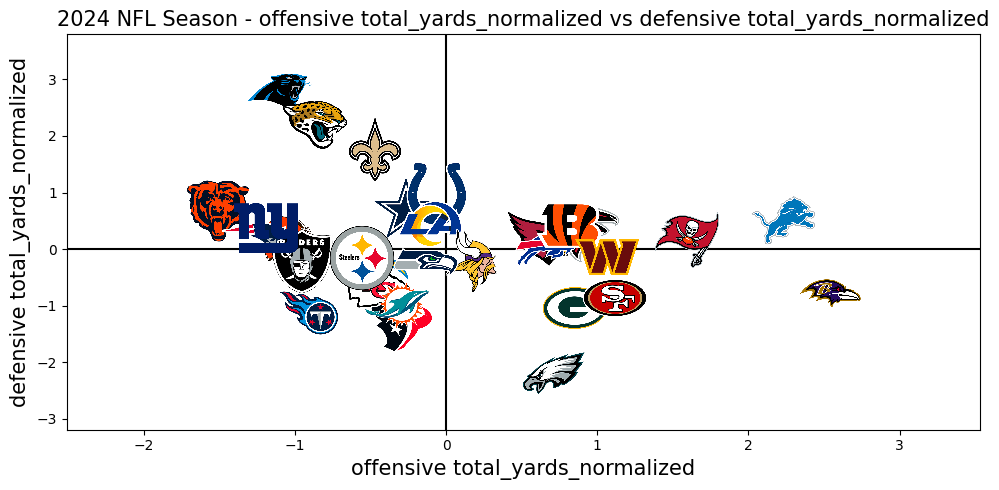

In [67]:
# Define plot size and autolayout
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.autolayout"] = True

# Define the x and y variables
x = df[x_stat]
y = df[y_stat]

# Define the image paths
paths = df["logo"]

# Define the plot
fig, ax = plt.subplots()

# Load the data into the plot
cntr=0
for x0, y0, path in zip(x, y, paths):
   ab = AnnotationBbox(getImage(path), (x0, y0), frameon=False)
   ax.add_artist(ab)
   cntr+=1

# Plot parameters
plt.xlim(np.min(df[x_stat])-1, np.max(df[x_stat])+1);
plt.ylim(np.min(df[y_stat])-1, np.max(df[y_stat])+1);
plt.axvline(0, color="black")
plt.axhline(0, color="black")
plt.title(f"2024 NFL Season - {x_stat} vs {y_stat}", fontdict={'fontsize':15});
plt.xlabel(x_stat, fontdict={'fontsize':15});
plt.ylabel(y_stat, fontdict={'fontsize':15});